# Compare Debug Profiles

Overlays several debug profiles' results side by side. **Load-only** — it reads
each profile's `debug_snapshots/<name>/live_summary.joblib` (written by
`validate_live_inference_epoched.ipynb`), so there is no MNE / inference re-run.

Three comparisons:
1. **CV AUC** per decoder (the real performance metric).
2. **Headline metrics table** — avg peak AUC, diagonal-dominance, mean target diagonal.
3. **Live-inference P(t)** per decoder on its own marker (inference-time behavior).

Run `validate_live_inference_epoched.ipynb` once per profile first (set `PROFILE`,
Run All) so each profile has a `live_summary.joblib`.

*Validation only — not part of the app.*

In [14]:
from pathlib import Path
import joblib
import numpy as np
import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt

# Locate repo root (dir containing debug_snapshots/).
_s = Path().resolve()
REPO_ROOT = next((p for p in [_s, *_s.parents] if (p / "debug_snapshots").is_dir()), None)
assert REPO_ROOT is not None, "Could not find debug_snapshots/ above the CWD."
DEBUG_ROOT = REPO_ROOT / "debug_snapshots"

# Profiles to compare (each needs a live_summary.joblib).
PROFILES = ["fl_logistic", "fl_lda", "fl_logistic_l1"]

summaries = {}
for name in PROFILES:
    f = DEBUG_ROOT / name / "live_summary.joblib"
    if not f.is_file():
        print(f"  [skip] {name}: no live_summary.joblib — run the live-inference notebook for it")
        continue
    summaries[name] = joblib.load(f)
    s = summaries[name]
    print(f"  [ok]   {name}: {len(s['tasks'])} decoders | avg peak AUC {s['average_peak_auc']:.3f}")

assert summaries, "No profile summaries found — run validate_live_inference_epoched.ipynb per profile first."
loaded = list(summaries)
PROFILE_COLORS = {name: plt.cm.tab10(i % 10) for i, name in enumerate(loaded)}
TASKS = summaries[loaded[0]]["tasks"]   # reference decoder list (first loaded profile)
print("\ncomparing:", loaded)

  [ok]   fl_logistic: 6 decoders | avg peak AUC 0.790
  [ok]   fl_lda: 6 decoders | avg peak AUC 0.692
  [ok]   fl_logistic_l1: 6 decoders | avg peak AUC 0.779

comparing: ['fl_logistic', 'fl_lda', 'fl_logistic_l1']


---
## 1. CV AUC per decoder (overlay)

One panel per decoder; each profile's diagonal cross-validated AUC overlaid.
Peak AUC per profile in the legend. This is the headline comparison.

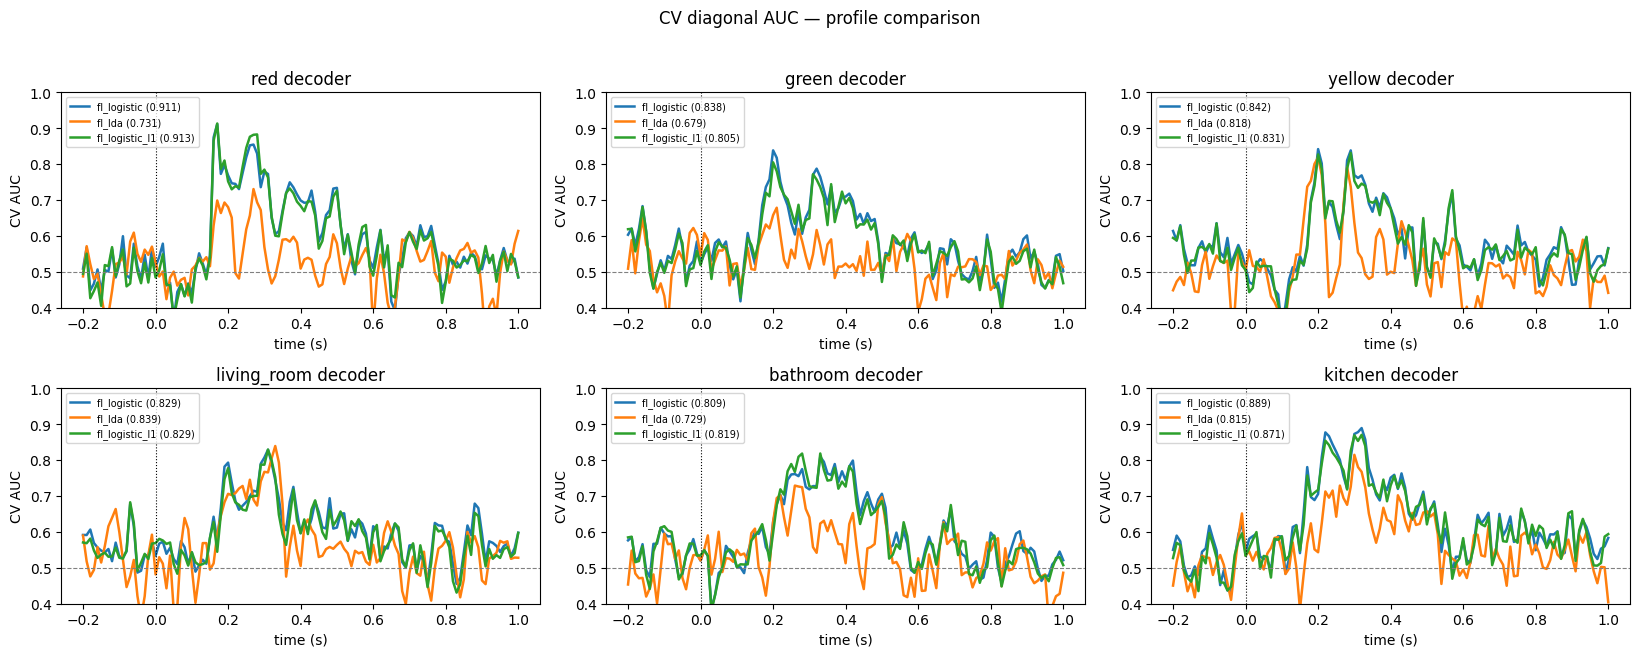

In [15]:
ncols = 3
nrows = (len(TASKS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.2 * nrows), squeeze=False)
for idx, task in enumerate(TASKS):
    ax = axes[idx // ncols][idx % ncols]
    for name in loaded:
        s = summaries[name]
        if task not in s["diagonal_auc"]:
            continue
        ax.plot(s["auc_times"], s["diagonal_auc"][task], color=PROFILE_COLORS[name],
                lw=1.8, label=f"{name} ({s['peak_auc'][task]:.3f})")
    ax.axhline(0.5, color="gray", ls="--", lw=0.8)
    ax.axvline(0.0, color="k", ls=":", lw=0.8)
    ax.set(title=task, ylim=(0.4, 1.0), xlabel="time (s)", ylabel="CV AUC")
    ax.legend(fontsize=7, loc="upper left")
for j in range(len(TASKS), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")
fig.suptitle("CV diagonal AUC — profile comparison", y=1.02)
plt.tight_layout(); plt.show()

---
## 2. Headline metrics

`diag_dom` = how many decoders whose own marker is the max in their row of the
per-trained-tp diagonal table. `mean_target_diag` = mean P(positive) of each
decoder on its own marker at its trained tp.

In [16]:
def dominance(s):
    n = 0
    for task in s["tasks"]:
        marker = s["task_pos_marker"].get(task)
        vals = {m: v for m, v in s["diag_at_tp"][task].items() if v is not None}
        if marker in vals and vals[marker] == max(vals.values()):
            n += 1
    return n

w = 18
header = "profile".ljust(w) + "avg_peakAUC".rjust(13) + "diag_dom".rjust(10) + "mean_target_diag".rjust(18) + "sugg_tp".rjust(9)
print(header)
print("-" * len(header))
for name in loaded:
    s = summaries[name]
    targets = [s["diag_at_tp"][t].get(s["task_pos_marker"].get(t)) for t in s["tasks"]]
    targets = [v for v in targets if v is not None]
    mean_t = sum(targets) / len(targets) if targets else float("nan")
    print(name.ljust(w)
          + f"{s['average_peak_auc']:.3f}".rjust(13)
          + f"{dominance(s)}/{len(s['tasks'])}".rjust(10)
          + f"{mean_t:.3f}".rjust(18)
          + f"{s['suggested_timepoint']:.2f}".rjust(9))

# Per-decoder peak AUC, profiles side by side.
print()
pw = 12
print("decoder".ljust(22) + "".join(n.rjust(pw) for n in loaded))
print("-" * (22 + pw * len(loaded)))
for task in TASKS:
    row = task.ljust(22)
    for name in loaded:
        v = summaries[name]["peak_auc"].get(task)
        row += (f"{v:.3f}" if v is not None else "n/a").rjust(pw)
    print(row)

profile             avg_peakAUC  diag_dom  mean_target_diag  sugg_tp
--------------------------------------------------------------------
fl_logistic               0.790       6/6             0.726     0.31
fl_lda                    0.692       5/6             0.545     0.27
fl_logistic_l1            0.779       6/6             0.725     0.31

decoder                fl_logistic      fl_ldafl_logistic_l1
----------------------------------------------------------
red decoder                  0.911       0.731       0.913
green decoder                0.838       0.679       0.805
yellow decoder               0.842       0.818       0.831
living_room decoder          0.829       0.839       0.829
bathroom decoder             0.809       0.729       0.819
kitchen decoder              0.889       0.815       0.871


---
## 3. Live-inference P(t) per decoder on its own marker (overlay)

One panel per decoder, showing that decoder's mean P(t) (±SEM) on its **own**
positive marker, one line per profile. Dotted vertical = each profile's trained
tp. (Optimistic on the training recording — read alongside the AUC above.)

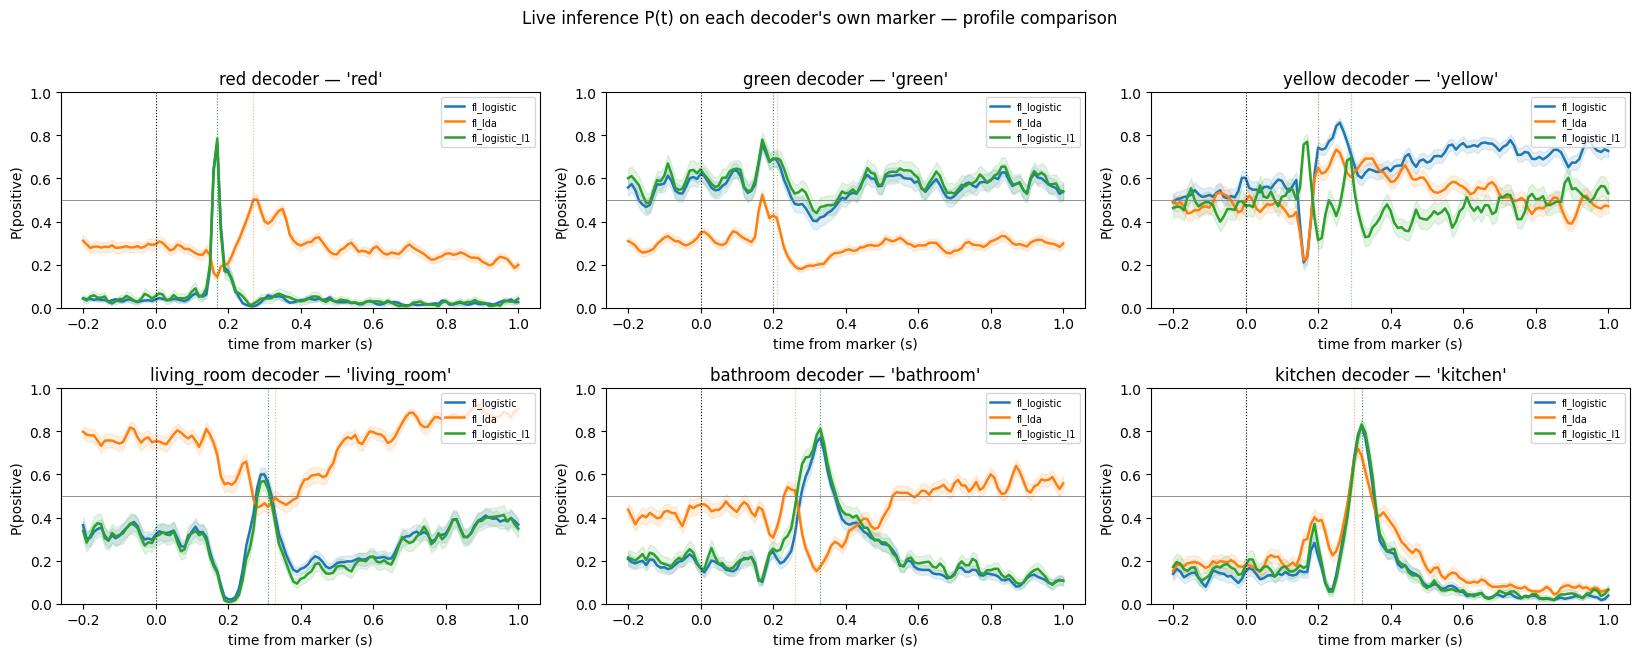

In [17]:
ncols = 3
nrows = (len(TASKS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.2 * nrows), squeeze=False)
for idx, task in enumerate(TASKS):
    ax = axes[idx // ncols][idx % ncols]
    marker = summaries[loaded[0]]["task_pos_marker"].get(task)
    for name in loaded:
        s = summaries[name]
        mk = s["task_pos_marker"].get(task)
        mean = s["pt_mean"].get(task, {}).get(mk)
        if mean is None:
            continue
        ax.plot(s["t_grid"], mean, color=PROFILE_COLORS[name], lw=1.8, label=name)
        sem = s["pt_sem"][task][mk]
        if sem is not None:
            ax.fill_between(s["t_grid"], mean - sem, mean + sem, color=PROFILE_COLORS[name], alpha=0.12)
        tp = s["tp_by_task"].get(task)
        if tp is not None:
            ax.axvline(tp, color=PROFILE_COLORS[name], ls=":", lw=0.8, alpha=0.6)
    ax.axhline(0.5, color="gray", lw=0.6)
    ax.axvline(0.0, color="k", ls=":", lw=0.8)
    ax.set(title=f"{task} — '{marker}'", ylim=(0, 1),
           xlabel="time from marker (s)", ylabel="P(positive)")
    ax.legend(fontsize=7, loc="upper right")
for j in range(len(TASKS), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")
fig.suptitle("Live inference P(t) on each decoder's own marker — profile comparison", y=1.02)
plt.tight_layout(); plt.show()